# Medistar Vision — Classificação de Imagens Satelitais com CNNs

Este notebook apresenta o treinamento e a comparação de duas arquiteturas de redes neurais convolucionais desenvolvidas do zero para classificação de imagens satelitais.

O objetivo é apoiar a plataforma Medistar na análise territorial de comunidades isoladas, classificando recortes de imagens em categorias como área urbana, vegetação densa, vegetação esparsa, agricultura, sombra e terreno exposto.

A classificação territorial pode auxiliar a priorização de atendimentos em regiões remotas, pois o tipo de ambiente identificado pode indicar dificuldade de acesso, isolamento geográfico ou presença de infraestrutura.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from keras.models import Sequential
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling
)
from keras.optimizers import Adam

In [2]:
# Caminhos principais
DATA_DIR = Path("../data/processed")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

OUTPUT_DIR = Path("../outputs")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Configurações do treinamento
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

EPOCHS_SIMPLE = 20
EPOCHS_DEEP = 30

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes encontradas:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print(f"\nTotal de classes: {num_classes}")

Found 2758 files belonging to 6 classes.
Found 590 files belonging to 6 classes.
Found 593 files belonging to 6 classes.
Classes encontradas:
0: agricultura
1: sombra
2: terreno_exposto
3: urbano
4: vegetacao_densa
5: vegetacao_esparsa

Total de classes: 6


In [4]:
normalization_layer = Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

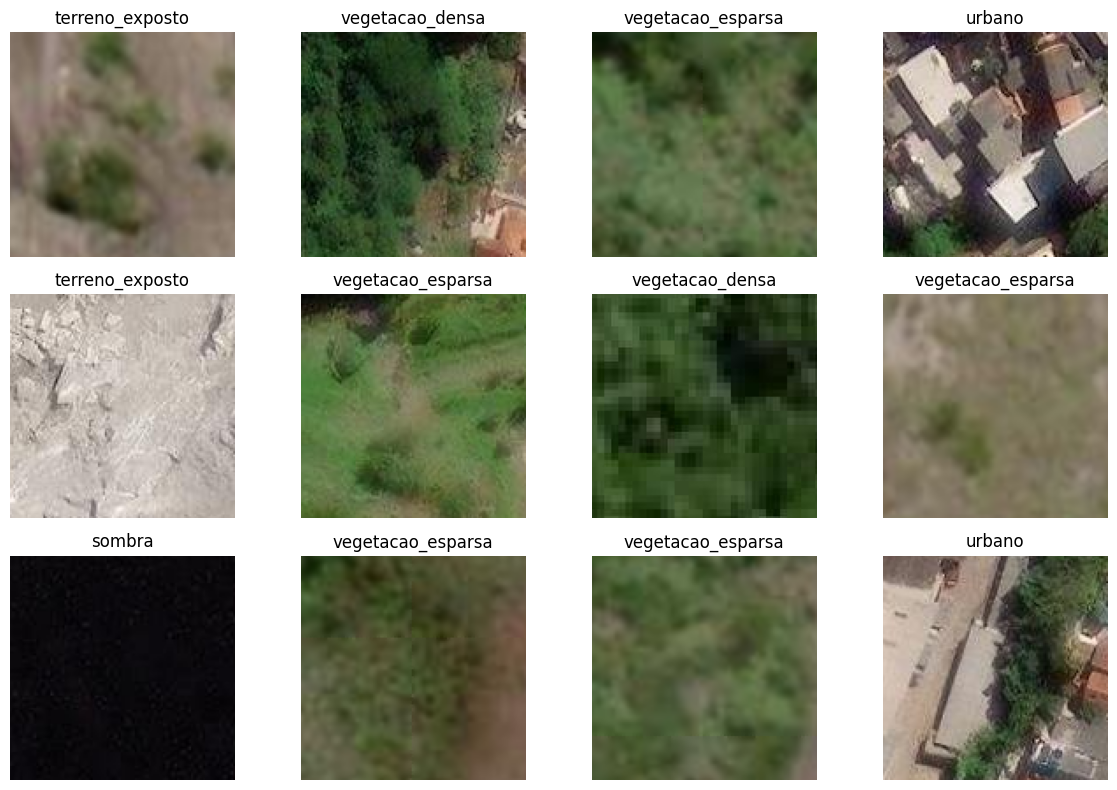

In [5]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        class_index = np.argmax(labels[i].numpy())
        plt.title(class_names[class_index])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def plot_training_history(history, model_name):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    # Gráfico de acurácia
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Treino")
    plt.plot(epochs_range, val_acc, label="Validação")
    plt.title(f"Acurácia - {model_name}")
    plt.xlabel("Épocas")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.grid(True)
    plt.savefig(PLOT_DIR / f"{model_name}_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Gráfico de loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Treino")
    plt.plot(epochs_range, val_loss, label="Validação")
    plt.title(f"Loss - {model_name}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(PLOT_DIR / f"{model_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.show()


def evaluate_model(model, dataset, model_name):
    loss, accuracy = model.evaluate(dataset)

    print(f"\nResultado no teste — {model_name}")
    print(f"Loss: {loss:.4f}")
    print(f"Acurácia: {accuracy:.4f}")

    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)

        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(xticks_rotation=45, values_format="d")
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.savefig(PLOT_DIR / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )

    print("\nClassification Report:")
    print(report)

    report_path = REPORT_DIR / f"{model_name}_classification_report.txt"

    with open(report_path, "w", encoding="utf-8") as file:
        file.write(report)

    return loss, accuracy

In [7]:
def build_simple_cnn(input_shape=(128, 128, 3), num_classes=6):
    model = Sequential(name="cnn_simples_baseline")

    # Bloco convolucional 1
    model.add(Conv2D(
        filters=16,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=input_shape
    ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Bloco convolucional 2
    model.add(Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Transição CNN -> MLP
    model.add(Flatten())

    # Parte MLP
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.3))

    # Camada de saída
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
simple_model = build_simple_cnn(
    input_shape=(128, 128, 3),
    num_classes=num_classes
)

simple_model.summary()

history_simple = simple_model.fit(
    train_ds,
    epochs=EPOCHS_SIMPLE,
    validation_data=val_ds
)

c:\Users\Natan\OneDrive\Documentos\GS_2026_01\COMPUTER_VISION\medistar-vision-acv\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_simples_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,742 (7.05 MB)

 Trainable params: 1,848,742 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6802 - loss: 0.8844 - val_accuracy: 0.7814 - val_loss: 0.5844
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8078 - loss: 0.5712 - val_accuracy: 0.8017 - val_loss: 0.5326
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8401 - loss: 0.4715 - val_accuracy: 0.8492 - val_loss: 0.4155
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8397 - loss: 0.4743 - val_accuracy: 0.8441 - val_loss: 0.4107
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8608 - loss: 0.3977 - val_accuracy: 0.8678 - val_loss: 0.3355
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8836 - loss: 0.3508 - val_accuracy: 0.8576 - val_loss: 0.3370
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8789 - loss: 0.3380 - val_accuracy: 0.8831 - val_loss: 0.3416
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8869 - loss: 0.3045 - val_accuracy: 0.8763 - v

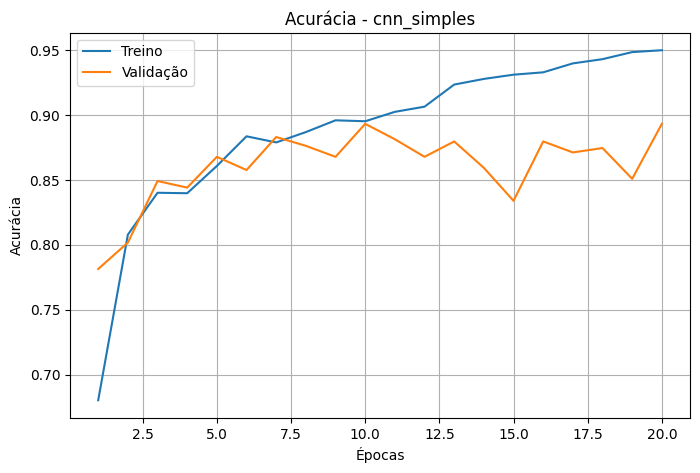

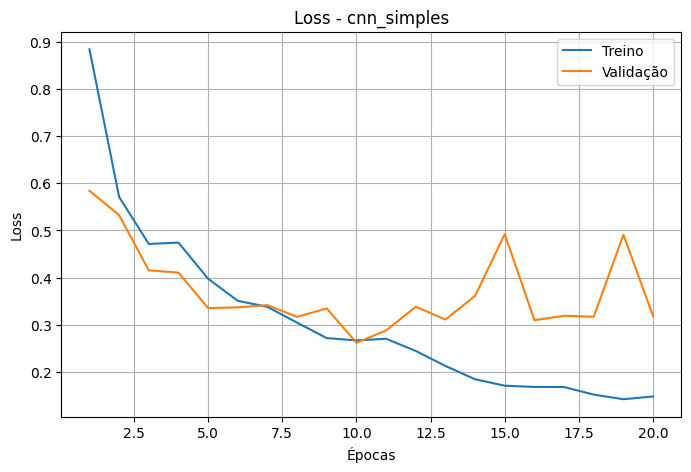

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9039 - loss: 0.3585

Resultado no teste — cnn_simples
Loss: 0.3585
Acurácia: 0.9039


<Figure size 1000x800 with 0 Axes>

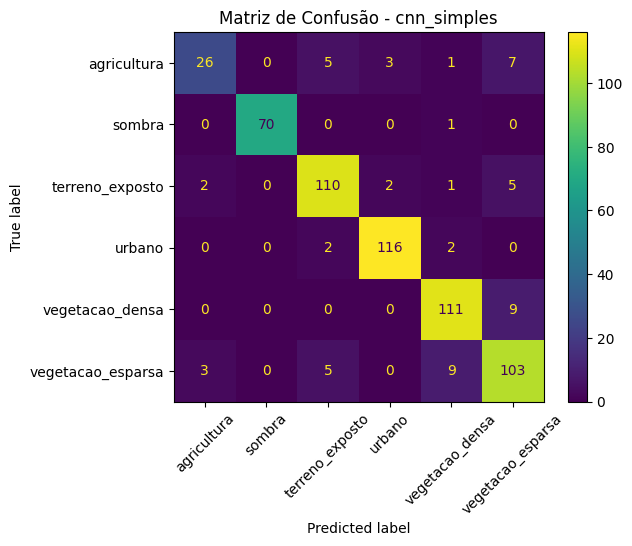


Classification Report:
                   precision    recall  f1-score   support

      agricultura       0.84      0.62      0.71        42
           sombra       1.00      0.99      0.99        71
  terreno_exposto       0.90      0.92      0.91       120
           urbano       0.96      0.97      0.96       120
  vegetacao_densa       0.89      0.93      0.91       120
vegetacao_esparsa       0.83      0.86      0.84       120

         accuracy                           0.90       593
        macro avg       0.90      0.88      0.89       593
     weighted avg       0.90      0.90      0.90       593

Modelo CNN simples salvo com sucesso.


In [9]:
plot_training_history(history_simple, "cnn_simples")

simple_loss, simple_acc = evaluate_model(
    simple_model,
    test_ds,
    "cnn_simples"
)

simple_model.save(MODEL_DIR / "cnn_simples.keras")

print("Modelo CNN simples salvo com sucesso.")

In [15]:
def build_deep_cnn(input_shape=(128, 128, 3), num_classes=6):
    model = Sequential(name="cnn_intermediaria")

    # Data Augmentation mais leve
    model.add(RandomFlip("horizontal", input_shape=input_shape))
    model.add(RandomRotation(0.03))
    model.add(RandomZoom(0.05))

    # Bloco convolucional 1
    model.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Bloco convolucional 2
    model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Bloco convolucional 3
    model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Transição CNN -> MLP
    model.add(Flatten())

    # Parte MLP
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))

    # Saída
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [16]:
deep_model = build_deep_cnn(
    input_shape=(128, 128, 3),
    num_classes=num_classes
)

deep_model.summary()

history_deep = deep_model.fit(
    train_ds,
    epochs=EPOCHS_DEEP,
    validation_data=val_ds
)

c:\Users\Natan\OneDrive\Documentos\GS_2026_01\COMPUTER_VISION\medistar-vision-acv\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "cnn_intermediaria"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,454 (16.36 MB)

 Trainable params: 4,288,454 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6751 - loss: 0.8606 - val_accuracy: 0.8085 - val_loss: 0.5575
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.8144 - loss: 0.5264 - val_accuracy: 0.8492 - val_loss: 0.4005
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8470 - loss: 0.4673 - val_accuracy: 0.8220 - val_loss: 0.5173
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8441 - loss: 0.4448 - val_accuracy: 0.8780 - val_loss: 0.3249
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8753 - loss: 0.3486 - val_accuracy: 0.8559 - val_loss: 0.4398
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8793 - loss: 0.3382 - val_accuracy: 0.8712 - val_loss: 0.3661
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.8927 - loss: 0.2810 - val_accuracy: 0.8288 - val_loss: 0.4451
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8992 - loss: 0.2819 - val_accuracy: 0.8983 - v

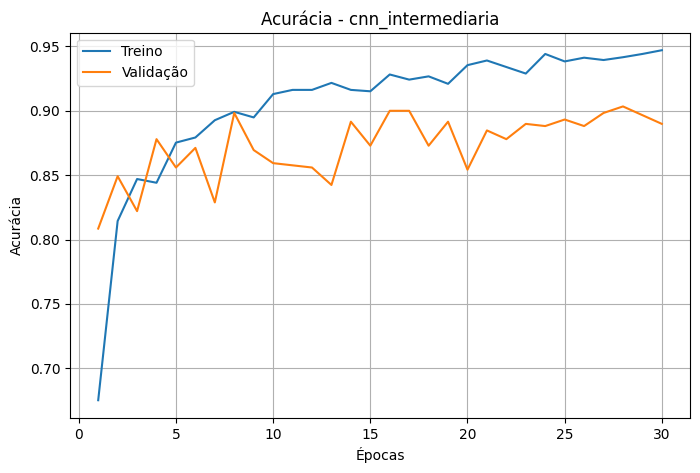

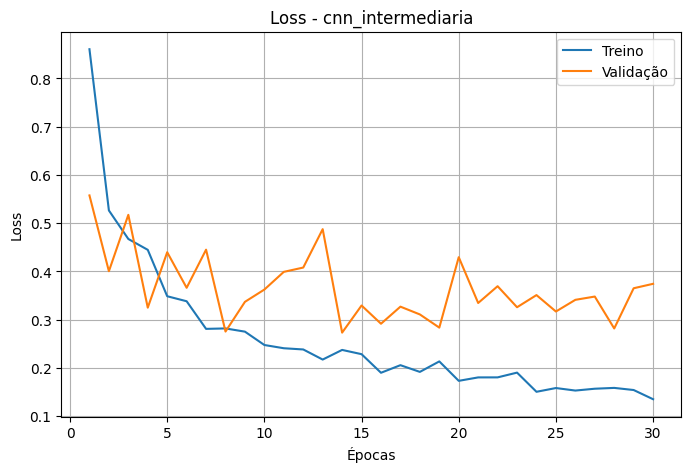

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9005 - loss: 0.3136

Resultado no teste — cnn_intermediaria
Loss: 0.3136
Acurácia: 0.9005


<Figure size 1000x800 with 0 Axes>

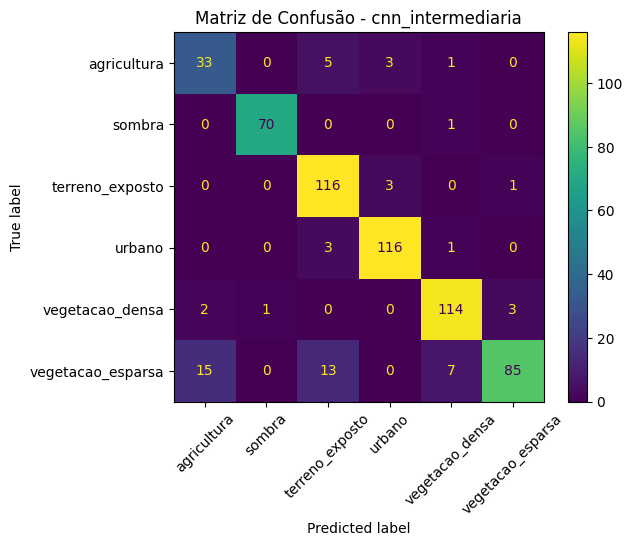


Classification Report:
                   precision    recall  f1-score   support

      agricultura       0.66      0.79      0.72        42
           sombra       0.99      0.99      0.99        71
  terreno_exposto       0.85      0.97      0.90       120
           urbano       0.95      0.97      0.96       120
  vegetacao_densa       0.92      0.95      0.93       120
vegetacao_esparsa       0.96      0.71      0.81       120

         accuracy                           0.90       593
        macro avg       0.89      0.89      0.89       593
     weighted avg       0.91      0.90      0.90       593

Modelo CNN intermediária salvo com sucesso.


In [17]:
plot_training_history(history_deep, "cnn_intermediaria")

deep_loss, deep_acc = evaluate_model(
    deep_model,
    test_ds,
    "cnn_intermediaria"
)

deep_model.save(MODEL_DIR / "cnn_intermediaria.keras")

print("Modelo CNN intermediária salvo com sucesso.")

In [18]:
comparison = {
    "Modelo": ["CNN Simples", "CNN Intermediária"],
    "Loss Teste": [simple_loss, deep_loss],
    "Acurácia Teste": [simple_acc, deep_acc]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)
comparison_df

,Modelo,Loss Teste,Acurácia Teste
0,CNN Simples,0.358494,0.903879
1,CNN Intermediária,0.313579,0.900506


In [19]:
if deep_acc >= simple_acc:
    best_model = deep_model
    best_name = "cnn_intermediaria"
    best_acc = deep_acc
else:
    best_model = simple_model
    best_name = "cnn_simples"
    best_acc = simple_acc

best_model.save(MODEL_DIR / "best_model.keras")

print(f"Melhor modelo: {best_name}")
print(f"Acurácia no teste: {best_acc:.4f}")
print(f"Modelo salvo em: {MODEL_DIR / 'best_model.keras'}")

Melhor modelo: cnn_simples
Acurácia no teste: 0.9039
Modelo salvo em: ..\outputs\models\best_model.keras


## Conclusão técnica

Foram treinadas duas arquiteturas de redes neurais convolucionais desenvolvidas do zero para classificação de recortes de imagens satelitais em seis classes territoriais: urbano, vegetação densa, vegetação esparsa, agricultura, sombra e terreno exposto.

A CNN Simples apresentou acurácia de 90,39% no conjunto de teste, superando a referência mínima de 88% definida para o projeto. A CNN Intermediária também obteve desempenho satisfatório, com 90,05% de acurácia e menor valor de loss no teste.

Apesar de a CNN Intermediária possuir maior capacidade de extração de características, com mais filtros convolucionais e data augmentation leve, a CNN Simples apresentou a melhor acurácia final. Isso indica que, para este dataset, uma arquitetura mais compacta foi suficiente para aprender os principais padrões visuais das classes, além de reduzir o risco de complexidade desnecessária.

O melhor modelo selecionado foi a CNN Simples, salvo como `best_model.keras`, por apresentar a maior acurácia no conjunto de teste. Esse modelo poderá ser utilizado na demonstração funcional do Medistar Vision para classificar novas imagens satelitais e apoiar a análise territorial de regiões isoladas.